In [15]:
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from snowflake_config import SNOWFLAKE_CONFIG

conn = snowflake.connector.connect(**SNOWFLAKE_CONFIG)
cursor = conn.cursor()

def run_query(sql):
    cursor.execute(sql)
    df = cursor.fetch_pandas_all()
    return df

print("Connected!")

Connected!


In [16]:
# fetch raw data from Snowflake, one row per cohort per month
ltv_df = run_query("""
    with first_purchase as (
        select
            user_id,
            cast(date_trunc('month', min(event_time)) as date) as cohort_month
        from fct_purchases
        group by 1
    ),

    cohort_sizes as (
        -- fix cohort size once at month 0
        select
            cohort_month,
            count(distinct user_id) as cohort_size
        from first_purchase
        group by 1
    ),

    monthly_revenue as (
        select
            p.user_id,
            cast(date_trunc('month', p.event_time) as date) as purchase_month,
            sum(p.price)                                     as monthly_revenue
        from fct_purchases p
        group by 1, 2
    ),

    cohort_revenue as (
        select
            f.cohort_month,
            datediff(
                'month',
                f.cohort_month,
                m.purchase_month
            )                        as months_since_cohort,
            sum(m.monthly_revenue)   as total_revenue
        from first_purchase f
        left join monthly_revenue m
            on f.user_id = m.user_id
        group by 1, 2
    )

    select
        r.cohort_month,
        r.months_since_cohort,
        s.cohort_size,
        r.total_revenue,
        round(r.total_revenue / s.cohort_size, 4) as avg_revenue_per_user
    from cohort_revenue r
    left join cohort_sizes s
        on r.cohort_month = s.cohort_month
    where r.months_since_cohort >= 0
    order by 1, 2
""")

ltv_df.head(20)

,COHORT_MONTH,MONTHS_SINCE_COHORT,COHORT_SIZE,TOTAL_REVENUE,AVG_REVENUE_PER_USER
0,2019-10-01,0,346141,2.290420e+08,661.7016
1,2019-10-01,1,346141,9.183552e+07,265.3125
2,2019-10-01,2,346141,8.364214e+07,241.6418
3,2019-10-01,3,346141,5.072188e+07,146.5353
4,2019-10-01,4,346141,6.056384e+07,174.9687
5,2019-10-01,5,346141,4.056483e+07,117.1916
6,2019-10-01,6,346141,1.733217e+07,50.0726
7,2019-10-01,7,346141,9.509696e+04,0.2747
8,2019-11-01,0,349618,1.826013e+08,522.2879
9,2019-11-01,1,349618,7.170479e+07,205.0947


In [17]:
# clean partial periods, same logic as cohort analysis
max_month_per_cohort = ltv_df.groupby(
    'COHORT_MONTH'
)['MONTHS_SINCE_COHORT'].max().reset_index()
max_month_per_cohort.columns = ['COHORT_MONTH', 'MAX_MONTH']

ltv_clean = ltv_df.merge(max_month_per_cohort, on='COHORT_MONTH')
ltv_clean = ltv_clean[
    ltv_clean['MONTHS_SINCE_COHORT'] < ltv_clean['MAX_MONTH']
].drop(columns='MAX_MONTH')

# also remove last cohort
ltv_clean = ltv_clean[
    ltv_clean['COHORT_MONTH'] < ltv_clean['COHORT_MONTH'].max()
]

# calculate cumulative LTV
ltv_clean = ltv_clean.sort_values(['COHORT_MONTH', 'MONTHS_SINCE_COHORT'])
ltv_clean['CUMULATIVE_LTV'] = ltv_clean.groupby(
    'COHORT_MONTH'
)['AVG_REVENUE_PER_USER'].cumsum()

ltv_clean[['COHORT_MONTH', 'MONTHS_SINCE_COHORT', 
           'AVG_REVENUE_PER_USER', 'CUMULATIVE_LTV']].head(20)

,COHORT_MONTH,MONTHS_SINCE_COHORT,AVG_REVENUE_PER_USER,CUMULATIVE_LTV
0,2019-10-01,0,661.7016,661.7016
1,2019-10-01,1,265.3125,927.0141
2,2019-10-01,2,241.6418,1168.6559
3,2019-10-01,3,146.5353,1315.1912
4,2019-10-01,4,174.9687,1490.1599
5,2019-10-01,5,117.1916,1607.3515
6,2019-10-01,6,50.0726,1657.4241
8,2019-11-01,0,522.2879,522.2879
9,2019-11-01,1,205.0947,727.3826
10,2019-11-01,2,107.4604,834.8430


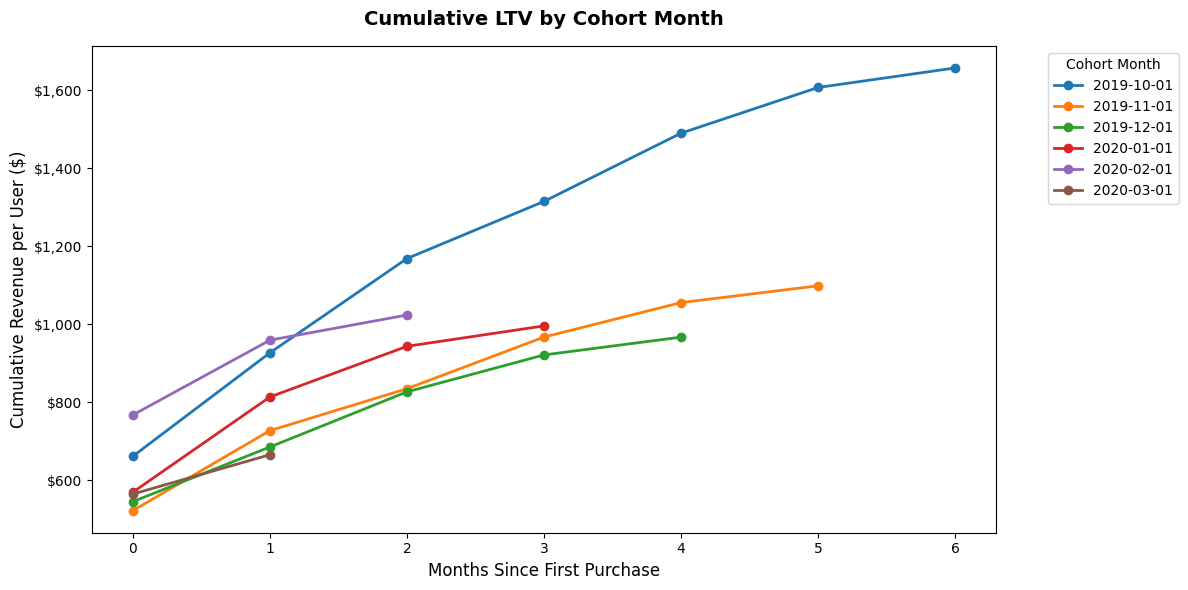

In [18]:
# visualize cumulative LTV per cohort
fig, ax = plt.subplots(figsize=(12, 6))

for cohort in ltv_clean['COHORT_MONTH'].unique():
    cohort_data = ltv_clean[ltv_clean['COHORT_MONTH'] == cohort]
    ax.plot(
        cohort_data['MONTHS_SINCE_COHORT'],
        cohort_data['CUMULATIVE_LTV'],
        marker='o',
        linewidth=2,
        label=str(cohort)
    )

ax.set_title(
    'Cumulative LTV by Cohort Month',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Cumulative Revenue per User ($)', fontsize=12)
ax.legend(title='Cohort Month', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.tight_layout()
plt.show()

In [19]:
# LTV prediction using growth rate multipliers (PRIMARY)

# step 1 — pivot actual LTV into cohort x month matrix
ltv_pivot = ltv_clean.pivot_table(
    index='COHORT_MONTH',
    columns='MONTHS_SINCE_COHORT',
    values='CUMULATIVE_LTV'
)

print("Actual LTV pivot:")
print(ltv_pivot.round(2))

Actual LTV pivot:
MONTHS_SINCE_COHORT       0       1        2        3        4        5  \
COHORT_MONTH                                                              
2019-10-01           661.70  927.01  1168.66  1315.19  1490.16  1607.35   
2019-11-01           522.29  727.38   834.84   967.27  1055.74  1098.69   
2019-12-01           545.25  685.42   826.83   921.46   967.13      NaN   
2020-01-01           569.53  813.72   943.58   995.90      NaN      NaN   
2020-02-01           767.62  959.36  1023.82      NaN      NaN      NaN   
2020-03-01           564.71  665.64      NaN      NaN      NaN      NaN   

MONTHS_SINCE_COHORT        6  
COHORT_MONTH                  
2019-10-01           1657.42  
2019-11-01               NaN  
2019-12-01               NaN  
2020-01-01               NaN  
2020-02-01               NaN  
2020-03-01               NaN  


In [20]:
# step 2 — calculate average growth multipliers across cohorts
multipliers = {}

for age in range(0, 6):
    # get cohorts that have both this month and next month
    valid = ltv_pivot[[age, age + 1]].dropna()
    if len(valid) >= 2:
        ratios = valid[age + 1] / valid[age]
        multipliers[age + 1] = ratios.mean()
        print(f"Month {age} → {age + 1}: multiplier = {multipliers[age + 1]:.4f} (based on {len(valid)} cohorts)")

print("\nAll multipliers:", {k: round(v, 4) for k, v in multipliers.items()})

Month 0 → 1: multiplier = 1.3180 (based on 6 cohorts)
Month 1 → 2: multiplier = 1.1683 (based on 5 cohorts)
Month 2 → 3: multiplier = 1.1135 (based on 4 cohorts)
Month 3 → 4: multiplier = 1.0914 (based on 3 cohorts)
Month 4 → 5: multiplier = 1.0597 (based on 2 cohorts)

All multipliers: {1: np.float64(1.318), 2: np.float64(1.1683), 3: np.float64(1.1135), 4: np.float64(1.0914), 5: np.float64(1.0597)}


In [21]:
# step 3 — predict missing values using multipliers
predicted_pivot = ltv_pivot.copy()

for cohort in predicted_pivot.index:
    for age in range(1, 7):
        # only predict if value is missing
        if pd.isna(predicted_pivot.loc[cohort, age]):
            prev_age = age - 1
            # find last known value
            if not pd.isna(predicted_pivot.loc[cohort, prev_age]):
                if age in multipliers:
                    predicted_pivot.loc[cohort, age] = (
                        predicted_pivot.loc[cohort, prev_age] * multipliers[age]
                    )

print("Predicted LTV pivot:")
print(predicted_pivot.round(2))

Predicted LTV pivot:
MONTHS_SINCE_COHORT       0       1        2        3        4        5  \
COHORT_MONTH                                                              
2019-10-01           661.70  927.01  1168.66  1315.19  1490.16  1607.35   
2019-11-01           522.29  727.38   834.84   967.27  1055.74  1098.69   
2019-12-01           545.25  685.42   826.83   921.46   967.13  1024.83   
2020-01-01           569.53  813.72   943.58   995.90  1086.88  1151.73   
2020-02-01           767.62  959.36  1023.82  1140.00  1244.14  1318.37   
2020-03-01           564.71  665.64   777.66   865.91   945.01  1001.39   

MONTHS_SINCE_COHORT        6  
COHORT_MONTH                  
2019-10-01           1657.42  
2019-11-01               NaN  
2019-12-01               NaN  
2020-01-01               NaN  
2020-02-01               NaN  
2020-03-01               NaN  


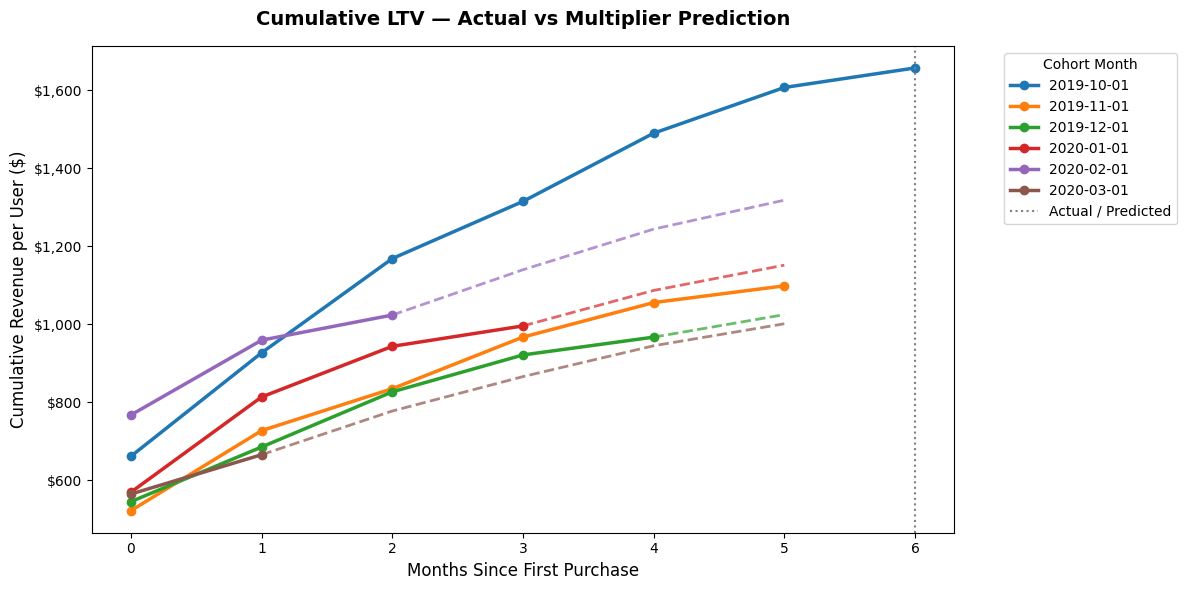

In [8]:
# visualize actual vs predicted
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10.colors

for i, cohort in enumerate(predicted_pivot.index):
    color = colors[i % len(colors)]
    cohort_label = str(cohort)
    
    # actual data points
    actual = ltv_pivot.loc[cohort].dropna()
    ax.plot(
        actual.index,
        actual.values,
        marker='o',
        linewidth=2.5,
        color=color,
        label=cohort_label
    )
    
    # predicted extension
    last_actual_month = actual.index.max()
    predicted = predicted_pivot.loc[cohort]
    future = predicted[predicted.index > last_actual_month].dropna()
    
    if len(future) > 0:
        # connect actual to predicted smoothly
        connection = pd.Series(
            [actual.iloc[-1]] + list(future.values),
            index=[last_actual_month] + list(future.index)
        )
        ax.plot(
            connection.index,
            connection.values,
            linestyle='--',
            linewidth=2,
            color=color,
            alpha=0.7
        )

# vertical line separating actual from predicted
last_actual = int(ltv_pivot.notna().sum(axis=1).max()) - 1
ax.axvline(
    x=last_actual,
    color='gray',
    linestyle=':',
    linewidth=1.5,
    label='Actual / Predicted'
)

ax.set_title(
    'Cumulative LTV — Actual vs Multiplier Prediction',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Cumulative Revenue per User ($)', fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
ax.legend(title='Cohort Month', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticks(range(0, 7))

plt.tight_layout()
plt.show()

In [22]:
# predisction summary table
summary = predicted_pivot.copy()
summary.index = [str(c) for c in summary.index]

# mark which values are actual vs predicted
is_predicted = ltv_pivot.isna()

print("Final LTV predictions ($ per user):")
print(summary.round(2).to_string())
print("\nCells marked as predicted:")
print(is_predicted.to_string())

Final LTV predictions ($ per user):
MONTHS_SINCE_COHORT       0       1        2        3        4        5        6
2019-10-01           661.70  927.01  1168.66  1315.19  1490.16  1607.35  1657.42
2019-11-01           522.29  727.38   834.84   967.27  1055.74  1098.69      NaN
2019-12-01           545.25  685.42   826.83   921.46   967.13  1024.83      NaN
2020-01-01           569.53  813.72   943.58   995.90  1086.88  1151.73      NaN
2020-02-01           767.62  959.36  1023.82  1140.00  1244.14  1318.37      NaN
2020-03-01           564.71  665.64   777.66   865.91   945.01  1001.39      NaN

Cells marked as predicted:
MONTHS_SINCE_COHORT      0      1      2      3      4      5      6
COHORT_MONTH                                                        
2019-10-01           False  False  False  False  False  False  False
2019-11-01           False  False  False  False  False  False   True
2019-12-01           False  False  False  False  False   True   True
2020-01-01           Fal

In [23]:
# power curve prediction (COMPARISON)
from scipy.optimize import curve_fit
import numpy as np
import warnings
warnings.filterwarnings('ignore')

def power_curve(t, a, b):
    return a * np.power(t + 1, b)

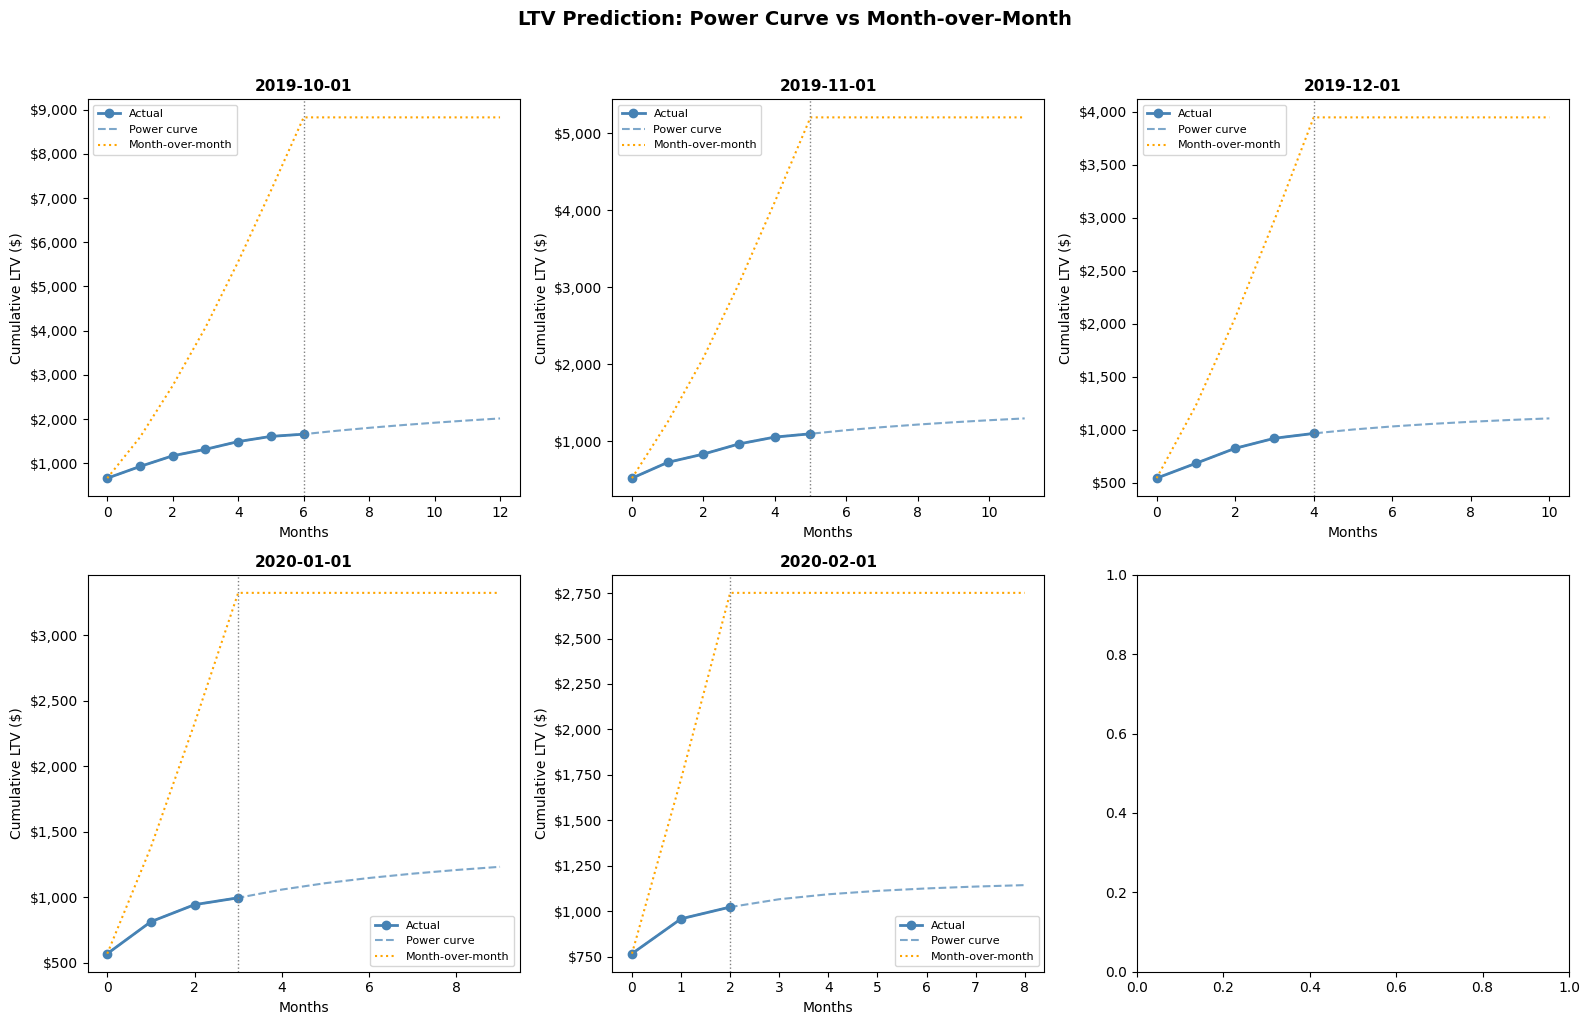

,cohort,last_actual_ltv,power_curve_6m,mom_6m
0,2019-10-01,1657.42,2013.68,8827.50
1,2019-11-01,1098.69,1298.34,5206.22
2,2019-12-01,967.13,1108.78,3946.09
3,2020-01-01,995.90,1232.45,3322.75
4,2020-02-01,1023.82,1144.52,2750.80


In [24]:
# fit to incremental revenue instead of cumulative

results_improved = []

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, cohort in enumerate(sorted(ltv_clean['COHORT_MONTH'].unique())):
    cohort_data = ltv_clean[
        ltv_clean['COHORT_MONTH'] == cohort
    ].sort_values('MONTHS_SINCE_COHORT')
    
    if len(cohort_data) < 3:
        continue
    
    x = cohort_data['MONTHS_SINCE_COHORT'].values
    y_incremental = cohort_data['AVG_REVENUE_PER_USER'].values
    y_cumulative = cohort_data['CUMULATIVE_LTV'].values
    
    try:
        # fit to incremental revenue (the decay curve)
        params, _ = curve_fit(
            power_curve, x, y_incremental,
            p0=[y_incremental[0], -0.5],  # hint: starts high, decays
            maxfev=5000
        )
        a, b = params
        
        # predict future incremental revenue
        last_month = x.max()
        future_months = np.arange(last_month + 1, last_month + 7)
        predicted_incremental = power_curve(future_months, a, b)
        predicted_incremental = np.maximum(predicted_incremental, 0)
        
        # build full cumulative curve
        all_months = np.concatenate([x, future_months])
        all_incremental = np.concatenate([y_incremental, predicted_incremental])
        all_cumulative = np.cumsum(all_incremental)
        
        # month-over-month approach for comparison
        avg_monthly_change = np.mean(np.diff(y_incremental[-3:]))
        mom_predictions = []
        last_val = y_incremental[-1]
        for _ in range(6):
            next_val = max(last_val + avg_monthly_change, 0)
            mom_predictions.append(next_val)
            last_val = next_val
        mom_cumulative = np.cumsum(
            np.concatenate([y_cumulative, mom_predictions])
        )

        # plot on subplot
        ax = axes[i]
        ax.plot(x, y_cumulative, 
                marker='o', color='steelblue', 
                linewidth=2, label='Actual')
        ax.plot(all_months, all_cumulative, 
                linestyle='--', color='steelblue',
                linewidth=1.5, alpha=0.7, label='Power curve')
        ax.plot(
            np.concatenate([x, future_months]),
            mom_cumulative[:len(x) + 6],
            linestyle=':', color='orange',
            linewidth=1.5, label='Month-over-month'
        )
        ax.axvline(x=last_month, color='gray', 
                   linestyle=':', linewidth=1)
        ax.set_title(str(cohort), fontsize=11, fontweight='bold')
        ax.set_xlabel('Months')
        ax.set_ylabel('Cumulative LTV ($)')
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
        )
        ax.legend(fontsize=8)
        
        results_improved.append({
            'cohort': str(cohort),
            'last_actual_ltv': round(y_cumulative[-1], 2),
            'power_curve_6m': round(all_cumulative[-1], 2),
            'mom_6m': round(float(mom_cumulative[len(x) + 5]), 2)
        })

    except Exception as e:
        print(f"Could not fit {cohort}: {e}")

plt.suptitle(
    'LTV Prediction: Power Curve vs Month-over-Month',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

pd.DataFrame(results_improved)

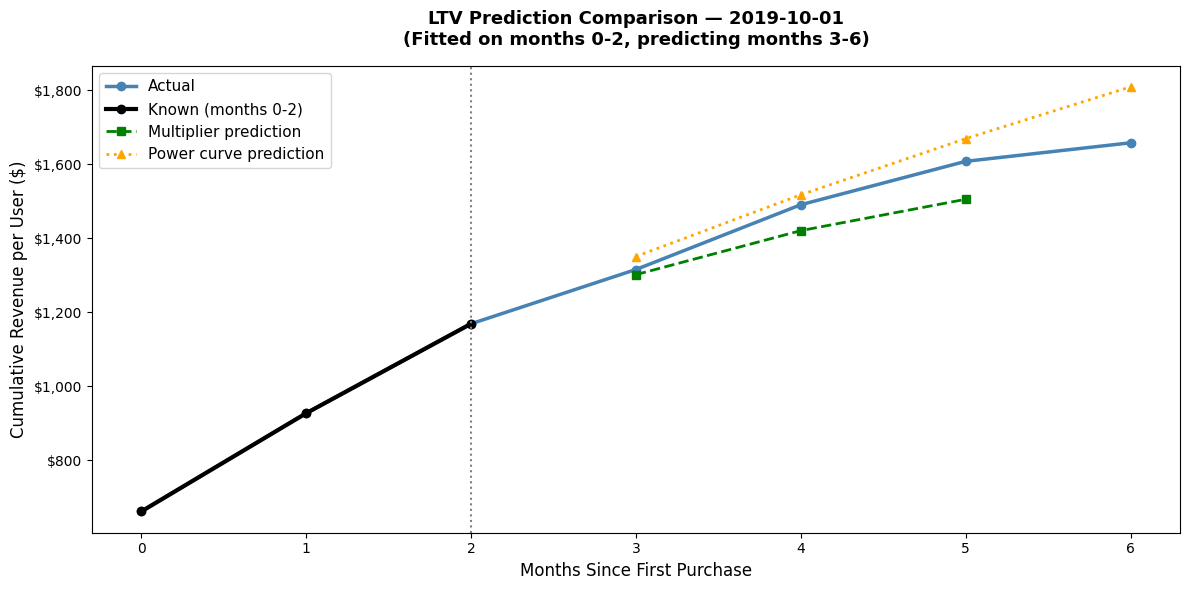

In [25]:
# comparison of predictions using backtesting scenario
# use only first 3 months as "known" data
oct_cohort = ltv_pivot.index[0]
oct_actual = ltv_pivot.iloc[0].dropna()

known = oct_actual.iloc[:3]
future_range = range(3, 7)

# multiplier prediction from month 2 forward
last_val = known.iloc[-1]
mult_predictions = {}
for age in future_range:
    if age in multipliers:
        last_val = last_val * multipliers[age]
        mult_predictions[age] = last_val

# power curve fitted on first 3 months only
params, _ = curve_fit(power_curve, known.index.values, 
                      known.values, maxfev=5000)
future_months = np.arange(3, 7)
power_predictions = power_curve(future_months, *params)

fig, ax = plt.subplots(figsize=(12, 6))

# actual full data
ax.plot(oct_actual.index, oct_actual.values,
        marker='o', linewidth=2.5,
        color='steelblue', label='Actual')

# known data used for fitting
ax.plot(known.index, known.values,
        marker='o', linewidth=3,
        color='black', label='Known (months 0-2)')

# multiplier prediction
ax.plot(
    list(mult_predictions.keys()),
    list(mult_predictions.values()),
    linestyle='--', linewidth=2,
    marker='s', color='green',
    label='Multiplier prediction'
)

# power curve prediction
ax.plot(
    future_months, power_predictions,
    linestyle=':', linewidth=2,
    marker='^', color='orange',
    label='Power curve prediction'
)

ax.axvline(x=2, color='gray', linestyle=':', linewidth=1.5)

ax.set_title(
    f'LTV Prediction Comparison — {oct_cohort}\n'
    f'(Fitted on months 0-2, predicting months 3-6)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Cumulative Revenue per User ($)', fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [26]:
# comparison table — multiplier vs power curve vs actual
print(f"Prediction Accuracy Comparison — {oct_cohort}")
print("(Both models fitted on months 0-2 only)\n")
print(f"{'Month':<8} {'Actual':>12} {'Multiplier':>12} {'Mult Error':>12} {'Power Curve':>12} {'Power Error':>12}")
print("-" * 70)

for age in future_range:
    if age in oct_actual.index:
        actual = oct_actual[age]
        
        mult_pred = mult_predictions.get(age, None)
        power_pred = power_curve(np.array([age]), *params)[0]
        
        mult_error = abs(mult_pred - actual) / actual * 100 if mult_pred else None
        power_error = abs(power_pred - actual) / actual * 100
        
        mult_str = f"${mult_pred:>10,.2f}" if mult_pred else "N/A"
        mult_err_str = f"{mult_error:>10.1f}%" if mult_error else "N/A"
        
        print(f"{age:<8} ${actual:>10,.2f} {mult_str} {mult_err_str} ${power_pred:>10,.2f} {power_error:>10.1f}%")

print("-" * 70)

# average errors
mult_errors = []
power_errors = []
for age in future_range:
    if age in oct_actual.index and age in mult_predictions:
        actual = oct_actual[age]
        mult_errors.append(abs(mult_predictions[age] - actual) / actual * 100)
        power_errors.append(abs(power_curve(np.array([age]), *params)[0] - actual) / actual * 100)

print(f"{'Avg Error':<8} {'':>12} {'':>12} {sum(mult_errors)/len(mult_errors):>11.1f}% {'':>12} {sum(power_errors)/len(power_errors):>11.1f}%")

Prediction Accuracy Comparison — 2019-10-01
(Both models fitted on months 0-2 only)

Month          Actual   Multiplier   Mult Error  Power Curve  Power Error
----------------------------------------------------------------------
3        $  1,315.19 $  1,301.27        1.1% $  1,350.24        2.7%
4        $  1,490.16 $  1,420.15        4.7% $  1,517.10        1.8%
5        $  1,607.35 $  1,504.88        6.4% $  1,668.62        3.8%
6        $  1,657.42 N/A N/A $  1,808.48        9.1%
----------------------------------------------------------------------
Avg Error                                   4.0%                      2.8%


In [28]:
## Prediction Quality Assessment

### Methods compared
'''
- Primary: Growth rate multipliers — average LTV ratios between consecutive months across all cohorts
- Comparison: Power curve fitting — mathematical decay curve fitted to cumulative LTV

### Backtesting results (October 2019 cohort)
Predicted months 3-6 using only months 0-2 as input:

| Month | Actual | Multiplier | Error | Power Curve | Error |
|-------|--------|------------|-------|-------------|-------|
| 3     | $1,315 | $1,301     | 1.1%  | $1,350      | 2.7%  |
| 4     | $1,490 | $1,420     | 4.7%  | $1,517      | 1.8%  |
| 5     | $1,607 | $1,505     | 6.4%  | $1,669      | 3.8%  |
| 6     | $1,657 | —          | —     | $1,808      | 9.1%  |

Power curve outperforms the multiplier method on average and can predict further into the future, however overshoots at month 6, 
suggesting it becomes overoptimistic for longer predictions. The multiplier method is more accurate at month 3 but loses accuracy faster over time.
Both methods perform acceptably at short horizons. 

### Recommendations for production
- Use the multiplier method as primary when explainability to non-technical stakeholders is a priority — more conservative and interpretable
- Use power curve for longer horizon predictions (4+ months)
- Retrain multipliers monthly as new cohort data becomes available
- Flag predictions based on fewer than 3 cohorts as low confidence
- Minimum 6 months of data before using LTV for budget decisions'''

'\n- Primary: Growth rate multipliers — average LTV ratios between consecutive months across all cohorts\n- Comparison: Power curve fitting — mathematical decay curve fitted to cumulative LTV\n\n### Backtesting results (October 2019 cohort)\nPredicted months 3-6 using only months 0-2 as input:\n\n| Month | Actual | Multiplier | Error | Power Curve | Error |\n|-------|--------|------------|-------|-------------|-------|\n| 3     | $1,315 | $1,301     | 1.1%  | $1,350      | 2.7%  |\n| 4     | $1,490 | $1,420     | 4.7%  | $1,517      | 1.8%  |\n| 5     | $1,607 | $1,505     | 6.4%  | $1,669      | 3.8%  |\n| 6     | $1,657 | —          | —     | $1,808      | 9.1%  |\n\nPower curve outperforms the multiplier method on average and can predict further into the future, however overshoots at month 6, \nsuggesting it becomes overoptimistic for longer predictions. The multiplier method is more accurate at month 3 but loses accuracy faster over time.\nBoth methods perform acceptably at short h